## Example application to parliament data

This notebook prepares the high-level migration dataset, constructs the inputs for DSL, runs the correction, and saves the resulting arrays for later analysis. The pipeline uses LLM committee predictions as surrogate labels and the available human annotations as gold-standard labels where present.

### Input data requirement

This notebook expects a JSON file that contains both model predictions and human annotator labels. First merge the annotator labels with the full dataset containing all model predictions.

In [23]:
# Load the parliamentary migration dataset and construct
# the inputs required for DSL:
# X: decade-level covariates
# Q: soft-label distributions from the LLM committee
# Y: soft-label distributions from the human annotators
# ids_kept: document identifiers retained after filtering

import json
import numpy as np
import matplotlib.pyplot as plt

# Choose label setup: "high" or "fine"
label_scheme = "fine"

# Model names inside row["models"]
llm_models = ['gptoss120b', 'qwen25', 'llama3']

# Columns used for the human annotation committee
human_cols = ['annotator1', 'annotator2', 'annotator3', 'annotator4', 'annotator5', 'annotator6', 'annotator7', 'annotator8', 'annotator9']

# Decades included in the analysis
decades = [
    '1860', '1870', '1880', '1890', '1900', '1910', '1920',
    '1940', '1950', '1960', '1970', '1980', '1990', '2000',
    '2010', '2020'
]

# Label setup
if label_scheme == "high":
    labels = ['solidarity', 'anti-solidarity', 'mixed', 'none']

    def normalize_label(label_str):
        """Map raw labels to the 4 high-level categories."""
        if not isinstance(label_str, str):
            return None
        label_str = label_str.strip().lower()
        if label_str in ['', 'nan', 'label not found']:
            return None
        if label_str.startswith('s.'):
            return 'solidarity'
        elif label_str.startswith('as.'):
            return 'anti-solidarity'
        elif label_str.startswith('mixed.'):
            return 'mixed'
        elif label_str.startswith('none.'):
            return 'none'
        else:
            return None

elif label_scheme == "fine":
    labels = [
        's.group-based', 's.exchange-based', 's.compassionate', 's.empathic',
        'as.group-based', 'as.exchange-based', 'as.compassionate', 'as.empathic',
        'mixed.none', 'none.none'
    ]

    def normalize_label(label_str):
        """Keep only labels that belong to the 10 fine-grained categories."""
        if not isinstance(label_str, str):
            return None
        label_str = label_str.strip().lower()
        if label_str in ['', 'nan', 'label not found']:
            return None
        return label_str if label_str in labels else None

else:
    raise ValueError("label_scheme must be 'high' or 'fine'")

label_index = {lab: i for i, lab in enumerate(labels)}
K = len(labels)

# Initialize data containers
X, Q, Y = [], [], []
ids_kept = []

#with open('Data/Migrant_1867-2025_AllModels.json', 'r') as f:
with open('/Users/aidakostikova/Desktop/FairGer/MethodPaper/GitHubFiles/CL/Data/ModelPredictedData/TEMP/Migrant_1867-2025_AllModelsAnnotators.json', 'r') as f:
    data = json.load(f)

# Iterate over all records and construct X, Q, and Y
for row in data:
    year = row['year']
    month = row['month']

    # Exclude 1940-1948 and pre-September 1949 from this analysis setup
    if 1940 <= year <= 1948:
        continue
    if year == 1949 and month < 9:
        continue

    decade = str(year)[:3] + '0'
    if decade not in decades:
        continue

    x = np.zeros(len(decades), dtype=float)
    x[decades.index(decade)] = 1.0

    # Construct the LLM committee distribution from row["models"][...]["extracted_label"]
    q = np.zeros(K, dtype=float)
    num_llm_votes = 0
    models_dict = row.get("models", {})

    for model_name in llm_models:
        raw_label = models_dict.get(model_name, {}).get("extracted_label", "")
        label = normalize_label(raw_label)
        if label is not None:
            q[label_index[label]] += 1.0
            num_llm_votes += 1

    # Skip rows without usable LLM predictions
    if num_llm_votes == 0:
        continue
    q /= num_llm_votes

    # Construct the human annotation distribution from top-level annotator fields
    y = np.zeros(K, dtype=float)
    num_human_votes = 0
    for col in human_cols:
        raw_label = row.get(col, '')
        label = normalize_label(raw_label)
        if label is not None:
            y[label_index[label]] += 1.0
            num_human_votes += 1

    if num_human_votes > 0:
        y /= num_human_votes
    else:
        y[:] = np.nan  # Mark samples without human annotation

    X.append(x)
    Q.append(q)
    Y.append(y)
    ids_kept.append(row["id"])

X = np.stack(X, axis=0)
Q = np.stack(Q, axis=0)
Y = np.stack(Y, axis=0)
ids_kept = np.array(ids_kept, dtype=object)

print(f"Label scheme: {label_scheme}")
print(f"Number of labels: {K}")
print(f"Successfully extracted {X.shape[0]} samples")
print(f"Samples with at least one human label: {np.sum(~np.isnan(Y).all(axis=1))}")
print("Labels:", labels)

Label scheme: fine
Number of labels: 10
Successfully extracted 62799 samples
Samples with at least one human label: 2051
Labels: ['s.group-based', 's.exchange-based', 's.compassionate', 's.empathic', 'as.group-based', 'as.exchange-based', 'as.compassionate', 'as.empathic', 'mixed.none', 'none.none']


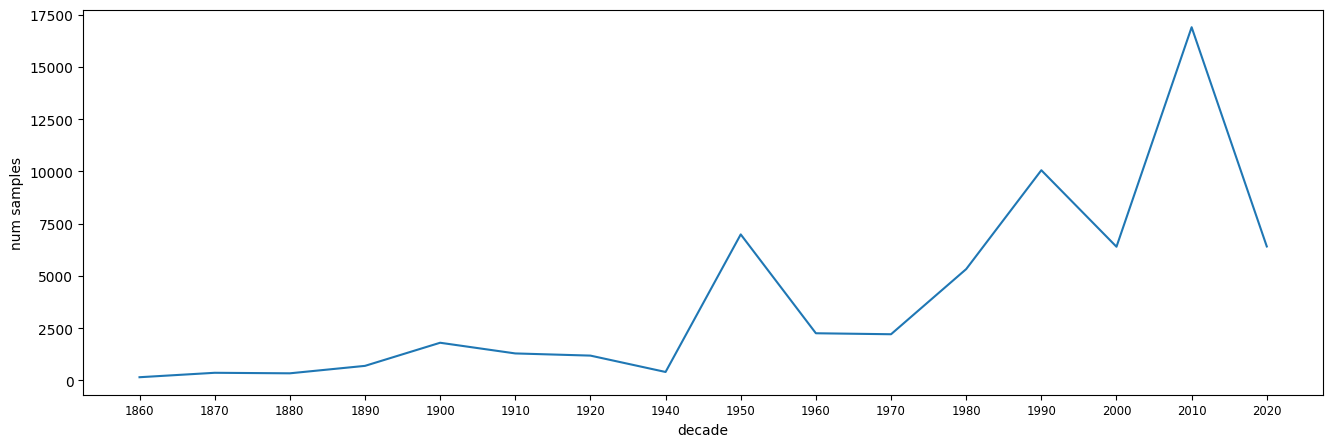

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize = (16, 5))
plt.plot(np.sum(X, axis = 0))
plt.xticks(range(len(decades)), decades, size='small')
plt.xlabel('decade')
plt.ylabel('num samples')
plt.show()

## DSL setup

This notebook uses the human annotations available in the dataset to define the labeled subset for DSL. We construct the annotation indicator `R` from rows with at least one human label and derive decade-level inclusion probabilities `pi` from the analysis setup. Together with the decade covariates `X` and the LLM committee distributions `Q`, these inputs are passed to the DSL routine.

In [25]:
import numpy as np

# Construct the DSL inputs for the full dataset

# R is True for samples with at least one human annotation
R = np.array([not np.isnan(y).all() and y.sum() > 0 for y in Y], dtype=bool)

# Construct decade-level inclusion probabilities
pi = np.zeros(X.shape[0])
for j in range(len(decades)):
    in_decade = X[:, j] > 0.5
    pi[in_decade] = np.mean(R[in_decade])

print(f"Label scheme: {label_scheme}")
print(f"Total samples: {X.shape[0]}")
print(f"Human-labeled: {np.sum(R)} ({100 * np.mean(R):.2f}%)")

Label scheme: fine
Total samples: 62799
Human-labeled: 2051 (3.27%)


In [20]:
# Run DSL using the available human-labeled subset Y[R, :]
from multi_label_dsl import multi_label_dsl
G, Ytilde = multi_label_dsl(X, Q, R, Y[R, :], pi)

In [26]:
# Save DSL outputs for downstream analysis
# - Ytilde_full_{suffix}.npy: DSL-adjusted class scores for all retained samples
# - G_full_{suffix}.npy: cross-fitted model predictions for all retained samples
# - ids_full_{suffix}.npy: sample IDs aligned row-wise with Ytilde and G

import numpy as np

suffix = f"{label_scheme}"

np.save(f"Ytilde_full_{suffix}.npy", Ytilde)
np.save(f"G_full_{suffix}.npy", G)
np.save(f"ids_full_{suffix}.npy", np.array(ids_kept, dtype=object))

print(
    f"Saved DSL outputs:\n"
    f"  - Ytilde_full_{suffix}.npy (DSL-adjusted class scores)\n"
    f"  - G_full_{suffix}.npy (cross-fitted predictions)\n"
    f"  - ids_full_{suffix}.npy (row-aligned sample IDs)"
)

Saved DSL outputs:
  - Ytilde_full_fine.npy (DSL-adjusted class scores)
  - G_full_fine.npy (cross-fitted predictions)
  - ids_full_fine.npy (row-aligned sample IDs)


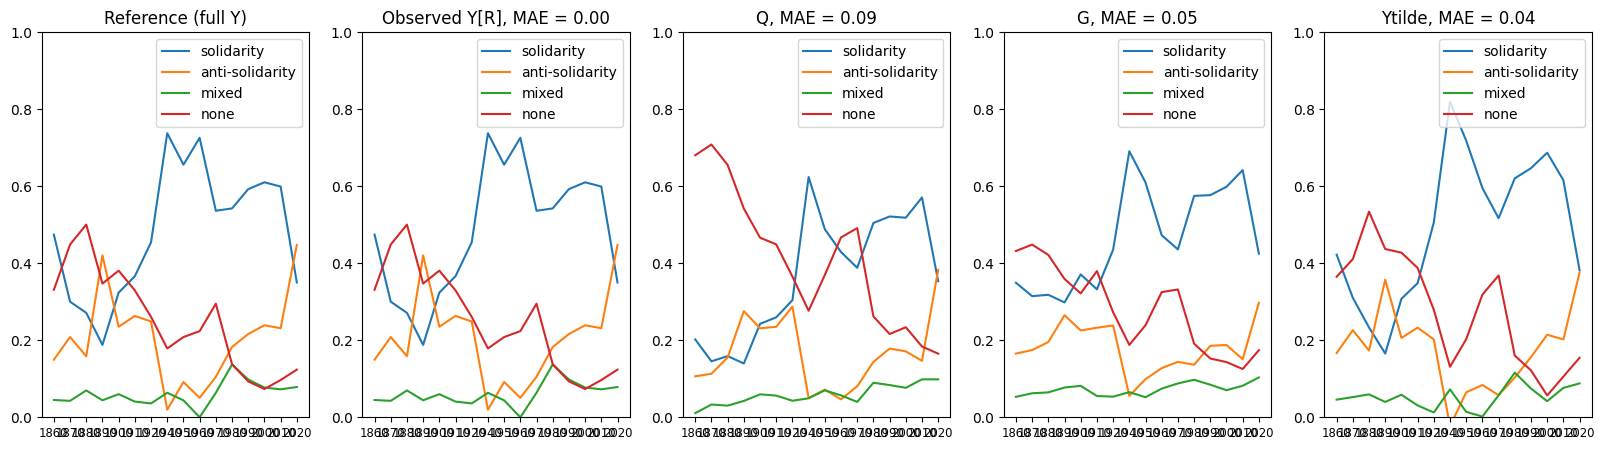

In [22]:
# Ytilde contains DSL-adjusted class scores for all samples.
# For human-labeled rows, these values can fall outside [0, 1] because
# the DSL correction reweights observed gold-standard labels.
# This is expected. We do not interpret individual rows of Ytilde as
# probability distributions. Instead, we aggregate Ytilde across decades
# and compare the resulting decade-level label summaries to the reference.

def label_distr_per_decade(X, arr):
    distr = np.zeros((len(decades), len(labels)))
    for j in range(len(decades)):
        in_decade = X[:, j] > 0.5
        decade_data = arr[in_decade, :]

        valid_rows = ~np.isnan(decade_data).all(axis=1)
        if np.sum(valid_rows) > 0:
            distr[j, :] = np.nanmean(decade_data[valid_rows, :], axis=0)
        else:
            distr[j, :] = np.zeros(len(labels))
    return distr

ref = label_distr_per_decade(X, Y)

plt.figure(figsize=(20, 5))

plt.subplot(1, 5, 1)
plt.plot(ref)
plt.legend(labels)
plt.xticks(range(len(decades)), decades, size='small')
plt.title('Reference (full Y)')
plt.ylim([0, 1])

plt.subplot(1, 5, 2)
distr = label_distr_per_decade(X[R, :], Y[R, :])
mae = np.mean(np.abs(distr - ref))
plt.plot(distr)
plt.legend(labels)
plt.xticks(range(len(decades)), decades, size='small')
plt.title(f'Observed Y[R], MAE = {mae:.2f}')
plt.ylim([0, 1])

plt.subplot(1, 5, 3)
distr = label_distr_per_decade(X, Q)
mae = np.mean(np.abs(distr - ref))
plt.plot(distr)
plt.legend(labels)
plt.xticks(range(len(decades)), decades, size='small')
plt.title(f'Q, MAE = {mae:.2f}')
plt.ylim([0, 1])

plt.subplot(1, 5, 4)
distr = label_distr_per_decade(X, G)
mae = np.mean(np.abs(distr - ref))
plt.plot(distr)
plt.legend(labels)
plt.xticks(range(len(decades)), decades, size='small')
plt.title(f'G, MAE = {mae:.2f}')
plt.ylim([0, 1])

plt.subplot(1, 5, 5)
distr = label_distr_per_decade(X, Ytilde)
mae = np.mean(np.abs(distr - ref))
plt.plot(distr)
plt.legend(labels)
plt.xticks(range(len(decades)), decades, size='small')
plt.title(f'Ytilde, MAE = {mae:.2f}')
plt.ylim([0, 1])

plt.show()